In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.io
import scipy
from scipy import signal
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import Isomap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture as GMM
from sklearn import preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
""" Define schema of datasets
"""

DATABASE = {
    'Database 1': ['female_1',
                  'female_2',
                  'female_3',
                  'male_1',
                  'male_2'],
    'Database 2': ['male_day_1',
                  'male_day_2',
                  'male_day_3']
}

COLUMNS = ['cyl_ch1', 
            'cyl_ch2', 
            'hook_ch1', 
            'hook_ch2', 
            'tip_ch1', 
            'tip_ch2', 
            'palm_ch1', 
            'palm_ch2', 
            'spher_ch1', 
            'spher_ch2', 
            'lat_ch1', 
            'lat_ch2']

LABELS = [
    'Spherical',
    'Tip',
    'Palmar',
    'Lateral',
    'Cylindrical',
    'Hook'
]

COL_MAPPINGS = {
            'cyl_ch1': 'Cylindrical', 
            'cyl_ch2': 'Cylindrical', 
            'hook_ch1': 'Hook', 
            'hook_ch2': 'Hook', 
            'tip_ch1': 'Tip', 
            'tip_ch2': 'Tip', 
            'palm_ch1': 'Palmar', 
            'palm_ch2': 'Palmar', 
            'spher_ch1': 'Spherical', 
            'spher_ch2': 'Spherical', 
            'lat_ch1': 'Lateral', 
            'lat_ch2': 'Lateral'
}

In [3]:
""" Preprocess and standardize dataset into a single dataframe table
"""

DB_NAME = 'Database 2'
dfs = []
for fname in DATABASE[DB_NAME]: 
    tmp_data = scipy.io.loadmat(f'./data/{DB_NAME}/{fname}')
    tmp_data = {k:v for k,v in tmp_data.items() if k in COLUMNS}
    for c in COLUMNS:
        tmp_dfx = pd.DataFrame(tmp_data[c])
        tmp_dfx['identifier'] = fname
        tmp_dfx['label'] = COL_MAPPINGS[c]
        dfs.append(pd.DataFrame(tmp_dfx))

        
dataset_ = pd.concat(dfs)

#combine coupled readouts
new_dfs = []
for lab in LABELS:
    new_temp = dataset_[dataset_['label'] == lab].values
    new_temp_comb = pd.DataFrame(np.concatenate((new_temp[:300,:2500],new_temp[300:,:2502]),axis=1))
    new_dfs.append(new_temp_comb)

dataset = pd.concat(new_dfs)
dataset.rename(columns={5001:'label', 5000:'identifier'}, inplace=True)
dataset.head()

df_features = dataset.iloc[:,:5000].copy()
df_labels = dataset.iloc[:, 5001]

In [4]:
label_dict = {
    'Spherical':0,
    'Tip':1,
    'Palmar':2,
    'Lateral':3,
    'Cylindrical':4,
    'Hook':5}

col = [label_dict[i] for i in df_labels.to_list()]

Fold 1/5:
Epoch 1/250
15/15 [==============================] - 6s 219ms/step - loss: 2.8984 - accuracy: 0.2958 - val_loss: 1.7719 - val_accuracy: 0.4667
Epoch 2/250
15/15 [==============================] - 3s 179ms/step - loss: 1.4708 - accuracy: 0.5382 - val_loss: 1.1261 - val_accuracy: 0.6833
Epoch 3/250
15/15 [==============================] - 3s 190ms/step - loss: 1.1866 - accuracy: 0.6278 - val_loss: 1.0257 - val_accuracy: 0.6806
Epoch 4/250
15/15 [==============================] - 3s 193ms/step - loss: 1.0534 - accuracy: 0.6715 - val_loss: 0.8688 - val_accuracy: 0.7944
Epoch 5/250
15/15 [==============================] - 3s 179ms/step - loss: 0.9599 - accuracy: 0.7049 - val_loss: 0.8530 - val_accuracy: 0.7694
Epoch 6/250
15/15 [==============================] - 3s 182ms/step - loss: 0.9194 - accuracy: 0.7153 - val_loss: 0.8062 - val_accuracy: 0.7972
Epoch 7/250
15/15 [==============================] - 4s 246ms/step - loss: 0.8678 - accuracy: 0.7347 - val_loss: 0.7873 - val_accura

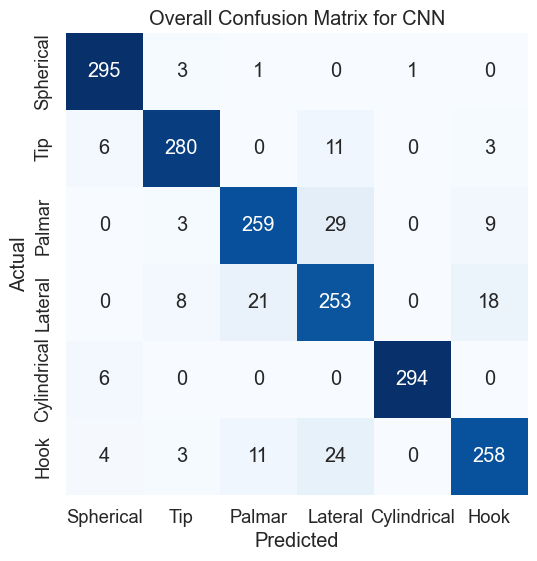

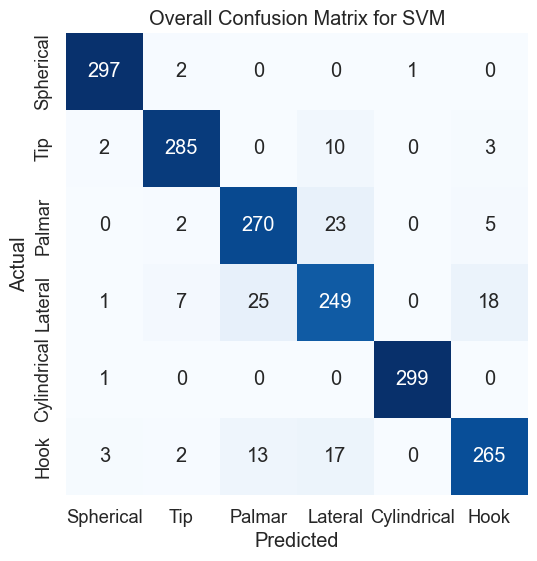

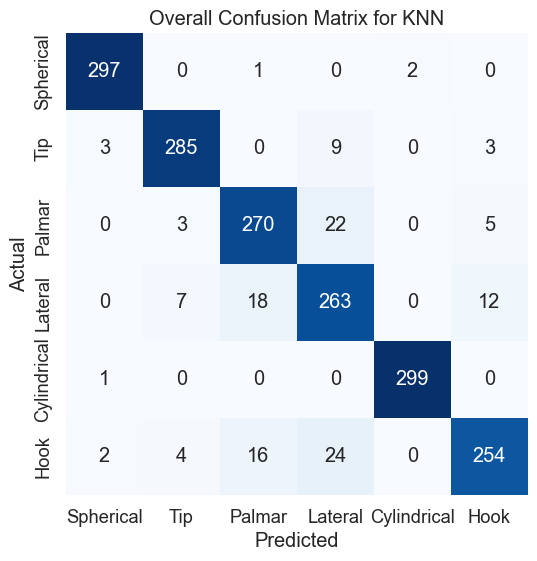

In [96]:
# Define a CNN model
def create_cnn_model(input_shape, num_classes):
    
    model = Sequential()
    
    model.add(Conv1D(4, kernel_size=2, activation='relu', input_shape=input_shape, padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
    
    model.add(Conv1D(8, kernel_size=2, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
    
    model.add(Conv1D(16, kernel_size=2, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
    
    model.add(Conv1D(32, kernel_size=2, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

    model.add(Conv1D(64, kernel_size=2, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
    
    model.add(Conv1D(128, kernel_size=2, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))

    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

# Prepare the data for CNN
X = df_features.values  # Features
y = df_labels.values  # Labels

# Input shape for the CNN model (adjust this based on your data)
input_shape = (X.shape[1], 1)  # Reshape for 1D Convolution

# Number of classes
num_classes = len(LABELS)

# Define the number of folds (k)
num_folds = 5
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=123)

# Lists to store evaluation metrics for each fold
cnn_accuracy_scores = []
cnn_precision_scores = []
cnn_recall_scores = []
cnn_f1_scores = []
svm_accuracy_scores = []
svm_precision_scores = []
svm_recall_scores = []
svm_f1_scores = []
knn_accuracy_scores = []
knn_precision_scores = []
knn_recall_scores = []
knn_f1_scores = []
y_true_all = []
y_pred_all_cnn = []
y_pred_all_svm = []
y_pred_all_knn = []
confusion_matrices_cnn = []
confusion_matrices_svm = []
confusion_matrices_knn = []

# Iterate over each fold
for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):

    print(f"Fold {fold}/{num_folds}:")
    
    # Split the data into training and testing sets for this fold
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    # Reshape the data to fit the CNN input shape
    X_train_fold = X_train_fold.reshape(X_train_fold.shape[0], X_train_fold.shape[1], 1)
    X_test_fold = X_test_fold.reshape(X_test_fold.shape[0], X_test_fold.shape[1], 1)

    # Encode class labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_fold)
    y_test_encoded = label_encoder.transform(y_test_fold)

    # Create and compile the CNN model for this fold
    cnn_model = create_cnn_model(input_shape, num_classes)
    cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

      # Cast the data to float32
    X_train_fold = X_train_fold.astype('float32')
    X_test_fold = X_test_fold.astype('float32')


    # Train the CNN model for this fold
    history = cnn_model.fit(X_train_fold, y_train_encoded, epochs=250, batch_size=100, validation_data=(X_test_fold, y_test_encoded))

    # Store the true labels for this fold
    y_true_all.extend(y_test_encoded)

    # Evaluate the CNN model on the test data for this fold
    y_pred_cnn = cnn_model.predict(X_test_fold)
    y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)
    cnn_accuracy = accuracy_score(y_test_encoded, y_pred_classes_cnn)
    
    # Compute additional evaluation metrics for CNN
    confusion_cnn = confusion_matrix(y_test_encoded, y_pred_classes_cnn)
    precision_cnn = precision_score(y_test_encoded, y_pred_classes_cnn, average='weighted')
    recall_cnn = recall_score(y_test_encoded, y_pred_classes_cnn, average='weighted')
    f1_cnn = f1_score(y_test_encoded, y_pred_classes_cnn, average='weighted')
    
    # Store the CNN evaluation metrics and predicted labels for this fold
    cnn_accuracy_scores.append(cnn_accuracy)
    cnn_precision_scores.append(precision_cnn)
    cnn_recall_scores.append(recall_cnn)
    cnn_f1_scores.append(f1_cnn)
    y_pred_all_cnn.extend(y_pred_classes_cnn)
    confusion_matrices_cnn.append(confusion_cnn)

    # Print and store the CNN evaluation metrics
    print(f"Fold {fold}/{num_folds} CNN Accuracy: {cnn_accuracy}")
    print(f"Fold {fold}/{num_folds} CNN Precision: {precision_cnn}")
    print(f"Fold {fold}/{num_folds} CNN Recall: {recall_cnn}")
    print(f"Fold {fold}/{num_folds} CNN F1-score: {f1_cnn}\n")

    # Feature extraction using the CNN model
    feature_extractor_cnn = Sequential(cnn_model.layers[:-1])  # Remove the last softmax layer
    X_train_features_cnn = feature_extractor_cnn.predict(X_train_fold)
    X_test_features_cnn = feature_extractor_cnn.predict(X_test_fold)

    # SVM classifier
    svm_classifier = SVC(kernel='linear', C=1, random_state=0)
    
    # Create a pipeline that scales features and then applies SVM
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', svm_classifier)
    ])

    # Train SVM on CNN features
    svm_pipeline.fit(X_train_features_cnn, y_train_encoded)
    
    # Evaluate SVM on CNN features
    svm_accuracy = svm_pipeline.score(X_test_features_cnn, y_test_encoded)
    
    # Predict using SVM
    y_pred_svm = svm_pipeline.predict(X_test_features_cnn)
    
    # Compute additional evaluation metrics for SVM
    confusion_svm = confusion_matrix(y_test_encoded, y_pred_svm)
    precision_svm = precision_score(y_test_encoded, y_pred_svm, average='weighted')
    recall_svm = recall_score(y_test_encoded, y_pred_svm, average='weighted')
    f1_svm = f1_score(y_test_encoded, y_pred_svm, average='weighted')
    
    # Store the SVM evaluation metrics and predicted labels for this fold
    svm_accuracy_scores.append(svm_accuracy)
    svm_precision_scores.append(precision_svm)
    svm_recall_scores.append(recall_svm)
    svm_f1_scores.append(f1_svm)
    y_pred_all_svm.extend(y_pred_svm)
    confusion_matrices_svm.append(confusion_svm)

    # Print and store the SVM evaluation metrics
    print(f"Fold {fold}/{num_folds} SVM Accuracy: {svm_accuracy}")
    print(f"Fold {fold}/{num_folds} SVM Precision: {precision_svm}")
    print(f"Fold {fold}/{num_folds} SVM Recall: {recall_svm}")
    print(f"Fold {fold}/{num_folds} SVM F1-score: {f1_svm}\n")

    # KNN classifier
    knn_classifier = KNeighborsClassifier(n_neighbors=5)
    
    # Create a pipeline that scales features and then applies KNN
    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', knn_classifier)
    ])

    # Train KNN on CNN features
    knn_pipeline.fit(X_train_features_cnn, y_train_encoded)
    
    # Evaluate KNN on CNN features
    knn_accuracy = knn_pipeline.score(X_test_features_cnn, y_test_encoded)
    
    # Predict using KNN
    y_pred_knn = knn_pipeline.predict(X_test_features_cnn)
    
    # Compute additional evaluation metrics for KNN
    confusion_knn = confusion_matrix(y_test_encoded, y_pred_knn)
    precision_knn = precision_score(y_test_encoded, y_pred_knn, average='weighted')
    recall_knn = recall_score(y_test_encoded, y_pred_knn, average='weighted')
    f1_knn = f1_score(y_test_encoded, y_pred_knn, average='weighted')
    
    # Store the KNN evaluation metrics and predicted labels for this fold
    knn_accuracy_scores.append(knn_accuracy)
    knn_precision_scores.append(precision_knn)
    knn_recall_scores.append(recall_knn)
    knn_f1_scores.append(f1_knn)
    y_pred_all_knn.extend(y_pred_knn)
    confusion_matrices_knn.append(confusion_knn)

    # Print and store the KNN evaluation metrics
    print(f"Fold {fold}/{num_folds} KNN Accuracy: {knn_accuracy}")
    print(f"Fold {fold}/{num_folds} KNN Precision: {precision_knn}")
    print(f"Fold {fold}/{num_folds} KNN Recall: {recall_knn}")
    print(f"Fold {fold}/{num_folds} KNN F1-score: {f1_knn}\n")

# Calculate the average evaluation metrics across all folds for CNN
average_cnn_accuracy = np.mean(cnn_accuracy_scores)
average_cnn_precision = np.mean(cnn_precision_scores)
average_cnn_recall = np.mean(cnn_recall_scores)
average_cnn_f1 = np.mean(cnn_f1_scores)

# Calculate the average evaluation metrics across all folds for SVM
average_svm_accuracy = np.mean(svm_accuracy_scores)
average_svm_precision = np.mean(svm_precision_scores)
average_svm_recall = np.mean(svm_recall_scores)
average_svm_f1 = np.mean(svm_f1_scores)

# Calculate the average evaluation metrics across all folds for KNN
average_knn_accuracy = np.mean(knn_accuracy_scores)
average_knn_precision = np.mean(knn_precision_scores)
average_knn_recall = np.mean(knn_recall_scores)
average_knn_f1 = np.mean(knn_f1_scores)

# Compute the overall confusion matrix for CNN
overall_confusion_matrix_cnn = sum(confusion_matrices_cnn)

# Compute the overall confusion matrix for SVM
overall_confusion_matrix_svm = sum(confusion_matrices_svm)

# Compute the overall confusion matrix for KNN
overall_confusion_matrix_knn = sum(confusion_matrices_knn)

# Print the overall evaluation metrics for CNN
print(f"Average CNN Test Accuracy across {num_folds} folds: {average_cnn_accuracy}")
print(f"Average CNN Test Precision across {num_folds} folds: {average_cnn_precision}")
print(f"Average CNN Test Recall across {num_folds} folds: {average_cnn_recall}")
print(f"Average CNN Test F1-score across {num_folds} folds: {average_cnn_f1}")

# Print the overall evaluation metrics for SVM
print(f"Average SVM Test Accuracy across {num_folds} folds: {average_svm_accuracy}")
print(f"Average SVM Test Precision across {num_folds} folds: {average_svm_precision}")
print(f"Average SVM Test Recall across {num_folds} folds: {average_svm_recall}")
print(f"Average SVM Test F1-score across {num_folds} folds: {average_svm_f1}")

# Print the overall evaluation metrics for KNN
print(f"Average KNN Test Accuracy across {num_folds} folds: {average_knn_accuracy}")
print(f"Average KNN Test Precision across {num_folds} folds: {average_knn_precision}")
print(f"Average KNN Test Recall across {num_folds} folds: {average_knn_recall}")
print(f"Average KNN Test F1-score across {num_folds} folds: {average_knn_f1}")

# Print the classification report for CNN
classification_report_cnn = classification_report(y_true_all, y_pred_all_cnn, target_names=LABELS)
print("Classification Report (Overall) for CNN:\n", classification_report_cnn)

# Optionally, you can do the same for SVM and KNN
# Print the classification report for SVM
classification_report_svm = classification_report(y_true_all, y_pred_all_svm, target_names=LABELS)
print("Classification Report (Overall) for SVM:\n", classification_report_svm)

# Print the classification report for KNN
classification_report_knn = classification_report(y_true_all, y_pred_all_knn, target_names=LABELS)
print("Classification Report (Overall) for KNN:\n", classification_report_knn)

# Plot the overall confusion matrix for CNN with colors
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust font size for clarity
sns.heatmap(overall_confusion_matrix_cnn, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Overall Confusion Matrix for CNN")
plt.show()

# Optionally, you can do the same for SVM and KNN
# Plot the overall confusion matrix for SVM with colors
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust font size for clarity
sns.heatmap(overall_confusion_matrix_svm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
             xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Overall Confusion Matrix for SVM")
plt.show()

# Plot the overall confusion matrix for KNN with colors
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Adjust font size for clarity
sns.heatmap(overall_confusion_matrix_knn, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
             xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Overall Confusion Matrix for KNN")
plt.show()      

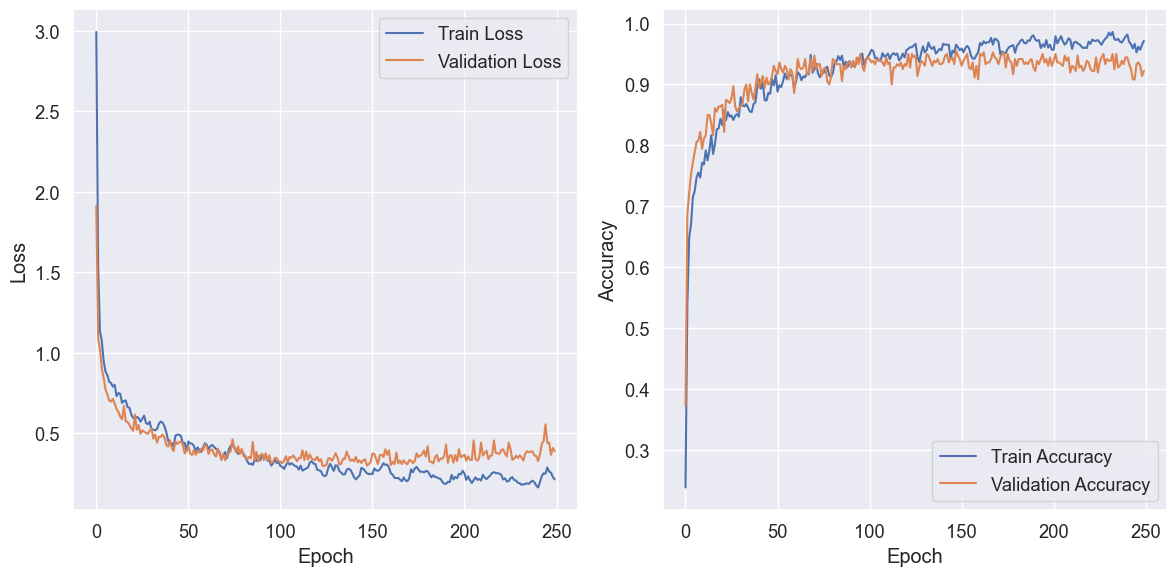

In [97]:

# Set the background color to white
plt.rcParams['figure.facecolor'] = 'white'

# Plot training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()

# Save the plot in the current directory with a relative file path
plt.savefig('plot.png')

# Show the plot (optional)
plt.show()